In [8]:
!pip install tensorflow

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import BatchNormalization
from sklearn.model_selection import train_test_split


In [2]:
df= pd.read_csv('C:\\Users\\PMLS\\Documents\\All Uni Work\\Data Science & AI\\skin_disease_data\\hmnist_28_28_RGB.csv')
X= df.drop('label', axis=1).values
y= df['label'].values

df.shape

(10015, 2353)

In [3]:
df.isnull().sum()

pixel0000    0
pixel0001    0
pixel0002    0
pixel0003    0
pixel0004    0
            ..
pixel2348    0
pixel2349    0
pixel2350    0
pixel2351    0
label        0
Length: 2353, dtype: int64

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [35]:
X_train[1,:]

array([159, 105, 143, ..., 172, 118, 153], shape=(2352,))

In [6]:
df.head()


,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [7]:
df.value_counts('label')

label
4    6705
6    1113
2    1099
1     514
0     327
5     142
3     115
Name: count, dtype: int64

In [8]:
df.shape

(10015, 2353)

Normalizing Images 


reshape(-1, 28, 28, 3) → reshapes your input data so that:

Each image is 28×28 pixels

Each pixel has 3 color channels (RGB)

-1 automatically infers the number of samples.

/ 255.0 → normalizes pixel values from 0–255 → 0–1 range.

In [9]:
X_train = X_train.reshape(-1, 28, 28, 3) 
X_test = X_test.reshape(-1, 28, 28, 3)

X_train = X_train / 255.0
X_test = X_test / 255.0

In [60]:


datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    # brightness_range=[0.6, 1.2],
    horizontal_flip=True
)

datagen.fit(X_train)


In [70]:
from tensorflow.keras import regularizers

#input shape (28 height , 28 width, 3 channels (RGB))

model = models.Sequential([
    #CNN operations
    #filters = number of feature detectors
    #kernel size = size of the feature detector 3x3
    #padding =  0; to keep the output size same as input size 

    layers.Conv2D(32, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001), input_shape=(28,28,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),

    # layers.Conv2D(48,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    # layers.BatchNormalization(),
    # layers.Conv2D(48,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    # layers.BatchNormalization(),
    # layers.MaxPooling2D((2,2)),
    # layers.Dropout(0.2),
    
    layers.Conv2D(64, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),


    layers.Conv2D(128,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.Conv2D(128,(3,3),activation=layers.LeakyReLU(alpha=0.01), padding='same',kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    # layers.Dropout(0.2),

    # layers.Conv2D(256, (3,3), activation=layers.LeakyReLU(alpha=0.01), padding='same', kernel_initializer='he_normal', kernel_regularizer=regularizers.l2(0.0001)),
    # layers.BatchNormalization(),
    # layers.MaxPooling2D((2,2)),
    # layers.Dropout(0.3),


    #ANN layers
    # flattening
    layers.GlobalAveragePooling2D(),

    # layers.Flatten(),
        
    # layers.Dense(256,activation='relu'),
    # layers.BatchNormalization(),
    # # layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.BatchNormalization(),
    # layers.Dense(64,activation='relu'),
    # layers.BatchNormalization(),
    # layers.Dropout(0.3),
    # layers.Dense(32,activation='relu'),
    # layers.BatchNormalization(),
    # layers.Dropout(0.2),

    layers.Dense(7, activation='softmax')
])


In [71]:
#learning rate adjustment
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-6)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)



In [72]:
optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003)

model.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [73]:
model_prediction = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),epochs=40,validation_data=(X_test, y_test),callbacks=[early_stop, checkpoint, reduce_lr])

Epoch 1/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 86ms/step - accuracy: 0.4754 - loss: 1.7757 - val_accuracy: 0.1188 - val_loss: 4.3086 - learning_rate: 3.0000e-04
Epoch 2/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 83ms/step - accuracy: 0.6419 - loss: 1.2614 - val_accuracy: 0.6176 - val_loss: 1.4605 - learning_rate: 3.0000e-04
Epoch 3/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.6867 - loss: 1.0452 - val_accuracy: 0.6435 - val_loss: 1.3173 - learning_rate: 3.0000e-04
Epoch 4/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.6957 - loss: 0.9803 - val_accuracy: 0.7149 - val_loss: 1.0993 - learning_rate: 3.0000e-04
Epoch 5/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 41s 91ms/step - accuracy: 0.6942 - loss: 0.9680 - val_accuracy: 0.6450 - val_loss: 1.0399 - learning_rate: 3.0000e-04
Epoch 6/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 22s 87ms/step - accuracy: 0.7091 - loss: 0.9114 - val_accuracy: 0.6725 - val_loss: 1.1071 - learning_rate: 3.0000e-04
Epoch 7/40
251/251 ━━━━━━━━━━━━━━━━━━━━ 21s 84ms/ste

In [74]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

print("Training Accuracy:", model_prediction.history['accuracy'][-1])
print("Training Loss:", model_prediction.history['loss'][-1])

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7294 - loss: 0.8328
Test Accuracy: 0.7294058799743652
Test Loss: 0.8327962756156921
Training Accuracy: 0.7568647265434265
Training Loss: 0.74415522813797


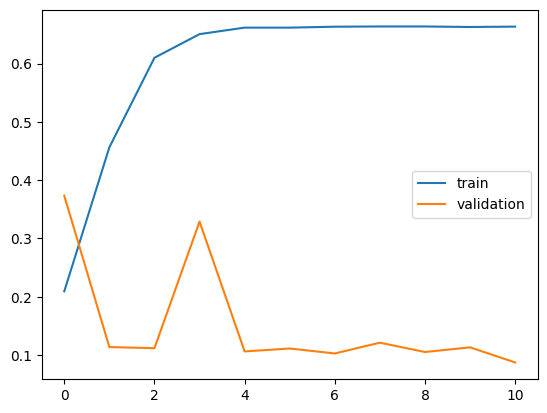

In [32]:
plt.plot(model_prediction.history['accuracy'], label='train')
plt.plot(model_prediction.history['val_accuracy'], label='validation')
plt.legend()
plt.show()